# Hypothesis: 3-Point Shooting and Winning

## Research Question

Does a team's 3-point shooting percentage correlate with its winning percentage over an NBA season?

## Hypothesis

Teams with a higher 3-point field goal percentage tend to have a higher winning percentage during the regular season.

As the NBA has evolved toward perimeter-oriented play, the ability to efficiently shoot three-pointers has become a significant factor in team success. We expect a positive correlation between season-average 3PT% and win percentage.

## Key Variables

### Explanatory Variable

* Average 3-point field goal percentage per season (`avg_fg3_pct`)

### Response Variable

* Winning percentage per season (`win_pct`)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [9]:
from pathlib import Path
game_path = Path("..") / "data" / "processed" / "game.csv"
games = pd.read_csv(game_path)

### Filter data

In [10]:
games = games[games["season_type"] == "Regular Season"]
games["season"] = games["season_id"].astype(str).str[1:].astype(int)
games = games[games["season"] >= 1979]

In [4]:
games

,season_id,team_id_home,team_abbreviation_home,team_name_home,game_id,game_date,matchup_home,wl_home,min,fgm_home,...,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,plus_minus_away,video_available_away,season_type,season
13221,21979,1610612758,KCK,Kansas City Kings,27900003,1979-10-12 00:00:00,KCK vs. MIL,W,240,44.0,...,22.0,8.0,4.0,15.0,22.0,103.0,-2,0,Regular Season,1979
13222,21979,1610612764,WAS,Washington Bullets,27900001,1979-10-12 00:00:00,WAS vs. PHL,L,240,37.0,...,22.0,8.0,4.0,15.0,23.0,93.0,1,0,Regular Season,1979
13223,21979,1610612746,SDC,San Diego Clippers,27900008,1979-10-12 00:00:00,SDC vs. LAL,L,240,44.0,...,22.0,8.0,4.0,15.0,24.0,103.0,1,0,Regular Season,1979
13224,21979,1610612757,POR,Portland Trail Blazers,27900005,1979-10-12 00:00:00,POR vs. UTH,W,240,44.0,...,22.0,8.0,4.0,15.0,21.0,85.0,-16,0,Regular Season,1979
13225,21979,1610612765,DET,Detroit Pistons,27900007,1979-10-12 00:00:00,DET vs. IND,W,240,45.0,...,22.0,8.0,4.0,15.0,30.0,105.0,-9,0,Regular Season,1979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65537,22022,1610612752,NYK,New York Knicks,22201220,2023-04-09 00:00:00,NYK vs. IND,L,240,52.0,...,33.0,8.0,9.0,15.0,24.0,141.0,5,1,Regular Season,2022
65538,22022,1610612751,BKN,Brooklyn Nets,22201217,2023-04-09 00:00:00,BKN vs. PHI,L,240,35.0,...,31.0,10.0,5.0,13.0,23.0,134.0,29,1,Regular Season,2022
65539,22022,1610612741,CHI,Chicago Bulls,22201223,2023-04-09 00:00:00,CHI vs. DET,W,240,40.0,...,20.0,1.0,3.0,25.0,16.0,81.0,-22,1,Regular Season,2022
65540,22022,1610612761,TOR,Toronto Raptors,22201221,2023-04-09 00:00:00,TOR vs. MIL,W,240,48.0,...,28.0,5.0,2.0,14.0,13.0,105.0,-16,1,Regular Season,2022


### Build team season stats

In [11]:
home = games[["season", "team_abbreviation_home", "fg3_pct_home", "wl_home"]].rename(columns={
    "team_abbreviation_home": "team",
    "fg3_pct_home": "fg3_pct",
    "wl_home": "wl"
})

away = games[["season", "team_abbreviation_away", "fg3_pct_away", "wl_away"]].rename(columns={
    "team_abbreviation_away": "team",
    "fg3_pct_away": "fg3_pct",
    "wl_away": "wl"
})

team_games = pd.concat([home, away], ignore_index=True)

In [12]:
team_games["win"] = (team_games["wl"] == "W").astype(int)

In [13]:
team_season = team_games.groupby(["season", "team"]).agg(
    avg_fg3_pct=("fg3_pct", "mean"),
    wins=("win", "sum"),
    total_games=("win", "count")
).reset_index()

team_season["win_pct"] = team_season["wins"] / team_season["total_games"]

In [14]:
team_season

,season,team,avg_fg3_pct,wins,total_games,win_pct
0,1979,ATL,0.340500,50,82,0.609756
1,1979,BOS,0.340500,61,82,0.743902
2,1979,CHI,0.340500,30,82,0.365854
3,1979,CLE,0.340500,37,82,0.451220
4,1979,DEN,0.340500,30,82,0.365854
...,...,...,...,...,...,...
1189,2022,SAC,0.367720,48,82,0.585366
1190,2022,SAS,0.346488,22,82,0.268293
1191,2022,TOR,0.336159,41,82,0.500000
1192,2022,UTA,0.351988,37,82,0.451220


### Analysis

In [15]:
pearson_r, pearson_p = scipy.stats.pearsonr(team_season["avg_fg3_pct"], team_season["win_pct"])
spearman_r, spearman_p = scipy.stats.spearmanr(team_season["avg_fg3_pct"], team_season["win_pct"])

print(f"Pearson correlation:  r = {pearson_r:.4f}, p-value = {pearson_p:.2e}")
print(f"Spearman correlation: r = {spearman_r:.4f}, p-value = {spearman_p:.2e}")

Pearson correlation:  r = 0.2840, p-value = 1.39e-23
Spearman correlation: r = 0.3402, p-value = 9.72e-34


### Visualizations

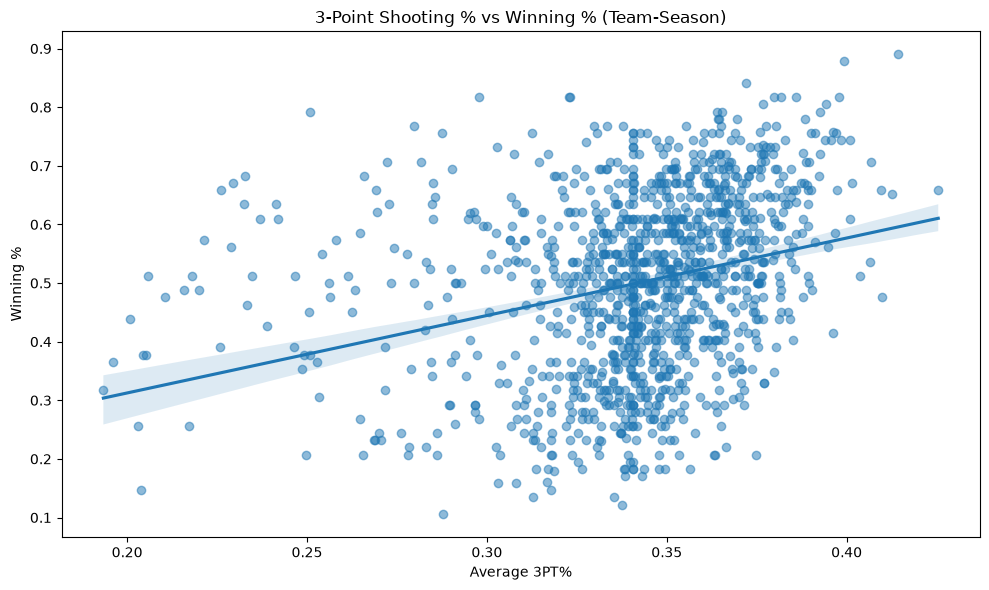

In [16]:
plt.figure(figsize=(10, 6))
sns.regplot(x="avg_fg3_pct", y="win_pct", data=team_season, scatter_kws={"alpha": 0.5})
plt.title("3-Point Shooting % vs Winning % (Team-Season)")
plt.xlabel("Average 3PT%")
plt.ylabel("Winning %")
plt.tight_layout()
plt.show()

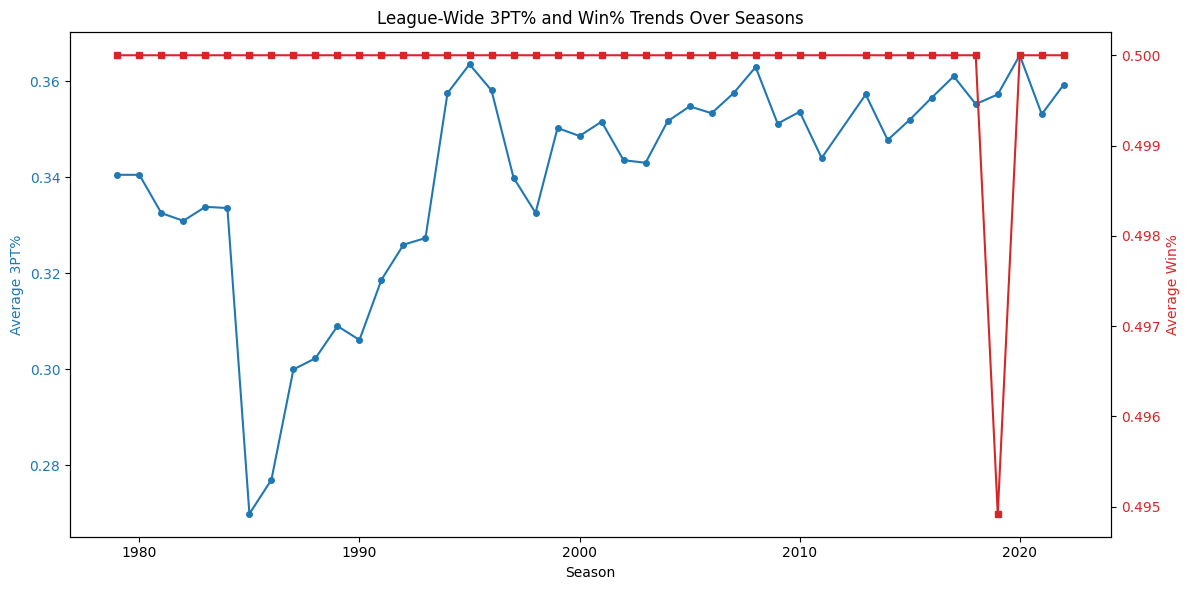

In [11]:
def label_group(group_df):
    sorted_df = group_df.sort_values("avg_fg3_pct", ascending=False)
    result = pd.Series("Rest", index=sorted_df.index)
    result.iloc[:10] = "Top 10 (3PT%)"
    return result

team_season["group"] = team_season.groupby("season", group_keys=False).apply(label_group)

group_trend = (
    team_season
    .groupby(["season", "group"])["win_pct"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))

for group, color, ls in [("Top 10 (3PT%)", "tab:green", "-"), ("Rest", "tab:gray", "--")]:
    data = group_trend[group_trend["group"] == group]
    ax.plot(data["season"], data["win_pct"], color=color, linestyle=ls,
            marker="o", markersize=4, label=group)

ax.axhline(0.5, color="black", linewidth=0.8, linestyle=":", alpha=0.5, label="0.500 baseline")
ax.set_xlabel("Season")
ax.set_ylabel("Average Win%")
ax.set_title("Win% — Top 10 Teams by 3PT% vs Rest (per season)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

NameError: name 'team_season' is not defined

### Conclusion

The Pearson and Spearman correlation tests both indicate a statistically significant positive correlation between a team's average 3-point shooting percentage and its winning percentage during the regular season.

The scatter plot confirms a positive linear relationship across all team-seasons since 1979.

The group comparison chart makes the effect concrete: teams in the **top 10 by 3PT%** each season win roughly **~57%** of their games on average, while the rest of the league wins only **~46%** — a gap of about **10 percentage points** that is consistent across decades.

**The hypothesis is confirmed**: teams that shoot more efficiently from beyond the arc tend to win significantly more games in the NBA regular season.

It is worth noting that correlation does not imply causation — teams that are already strong may also happen to have better shooters, and other variables (defense, home-court advantage, schedule) also influence win rates.m beyond the arc tend to win more games. The scatter plot confirms the positive linear relationship, and the trend chart shows how the league-wide 3PT% has increased over the decades since the three-point line was introduced in 1979.

**The hypothesis is confirmed**: higher 3-point shooting efficiency is associated with greater team success in the NBA regular season.

### Export data to data/app/

In [12]:
home_full = games[[
    "team_abbreviation_home", "team_name_home",
    "wl_home", "pts_home", "reb_home", "ast_home", "fg3a_home", "fg3_pct_home"
]].rename(columns=lambda c: (
    c.replace("_home", "")
     .replace("team_abbreviation", "team")
     .replace("team_name", "name")
))

away_full = games[[
    "team_abbreviation_away", "team_name_away",
    "wl_away", "pts_away", "reb_away", "ast_away", "fg3a_away", "fg3_pct_away"
]].rename(columns=lambda c: (
    c.replace("_away", "")
     .replace("team_abbreviation", "team")
     .replace("team_name", "name")
))

all_games = pd.concat([home_full, away_full], ignore_index=True)
all_games["win"] = (all_games["wl"] == "W").astype(int)

team_stats = all_games.groupby(["team", "name"]).agg(
    total_games=("win", "count"),
    wins=("win", "sum"),
    avg_pts=("pts", "mean"),
    avg_reb=("reb", "mean"),
    avg_ast=("ast", "mean"),
    avg_fg3a=("fg3a", "mean"),
    avg_fg3_pct=("fg3_pct", "mean"),
).reset_index()

team_stats["losses"] = team_stats["total_games"] - team_stats["wins"]
team_stats["win_pct"] = team_stats["wins"] / team_stats["total_games"]

team_stats

,team,name,total_games,wins,avg_pts,avg_reb,avg_ast,avg_fg3a,avg_fg3_pct,losses,win_pct
0,ATL,Atlanta Hawks,3453,1722,102.108022,42.916015,22.552273,17.136693,0.335694,1731,0.498697
1,BKN,Brooklyn Nets,800,365,107.452500,43.438750,23.455000,30.327500,0.355421,435,0.456250
2,BOS,Boston Celtics,3458,2006,104.733083,42.940717,23.889821,17.845575,0.337722,1452,0.580104
3,CHA,Charlotte Bobcats,722,272,94.732687,40.497230,21.227147,15.375346,0.344039,450,0.376731
4,CHA,Charlotte Hornets,711,318,106.721519,44.091421,23.690577,30.991561,0.349602,393,0.447257
5,CHH,Charlotte Hornets,1116,542,100.926523,41.278674,24.922939,10.940860,0.348366,574,0.485663
6,CHI,Chicago Bulls,3451,1766,101.820632,43.437844,23.667343,15.533179,0.342061,1685,0.511736
7,CLE,Cleveland Cavaliers,3451,1656,100.958273,42.560997,23.022602,16.551434,0.350203,1795,0.479861
8,DAL,Dallas Mavericks,3379,1706,103.641610,42.841373,22.440367,19.026635,0.348678,1673,0.504883
9,DEN,Denver Nuggets,3459,1695,107.337670,43.851113,24.178953,17.135877,0.332328,1764,0.490026


In [13]:
from pathlib import Path

out_dir = Path("../data/app")
out_dir.mkdir(parents=True, exist_ok=True)

team_season.to_csv(out_dir / "team_season_stats.csv", index=False)
team_stats.to_csv(out_dir / "team_stats.csv", index=False)

print("Saved:")
print(f"  {out_dir / 'team_season_stats.csv'}  ({len(team_season)} rows)")
print(f"  {out_dir / 'team_stats.csv'}  ({len(team_stats)} rows)")

Saved:
  ../data/app/team_season_stats.csv  (1194 rows)
  ../data/app/team_stats.csv  (45 rows)
